# 5. Tilt magnitude and depth-dependent environmental mismatch

This notebook tests whether large tilt occurs where deeper parts of the eddy encounter bathymetry or PV conditions missed by the shallow centre.

In [5]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

HERE = Path.cwd().resolve()
ANALYSIS_ROOT = next((p for p in (HERE, *HERE.parents) if (p / "seacofs_tilt_tools.py").exists()), None)
if ANALYSIS_ROOT is None:
    raise FileNotFoundError("Run inside seacofs_eddy_tilt_analysis or one of its subfolders")
if str(ANALYSIS_ROOT) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_ROOT))
if str(HERE) not in sys.path:
    sys.path.insert(0, str(HERE))

import seacofs_tilt_tools as tilt
import depth_pv_tools as dpt

sns.set_theme(style="whitegrid", context="notebook")
DOMINANCE_FACTOR = 2.0
TARGET_DEPTHS_M = (0, 200, 500, 700, 1000)
MIN_TILT_KM = 5.0

depth_df = tilt.add_pv_gradient_terms(source="depth")
snapshot_df = tilt.add_pv_gradient_terms(source="depth_snapshot")
dpt.validate_depth_tables(depth_df, snapshot_df)
DEPTHS = dpt.nearest_cached_depths(depth_df, TARGET_DEPTHS_M)
comparison = dpt.add_surface_differences(depth_df, DOMINANCE_FACTOR)
matched = dpt.matched_depth_rows(comparison, DEPTHS)
palette = {"AE": "r", "CE": "b"}
depth_cmap = plt.get_cmap("viridis")
depth_colours = dict(zip(DEPTHS, depth_cmap(np.linspace(.08, .92, len(DEPTHS)))))
depth_labels = {z: f"{z:g} m" for z in DEPTHS}


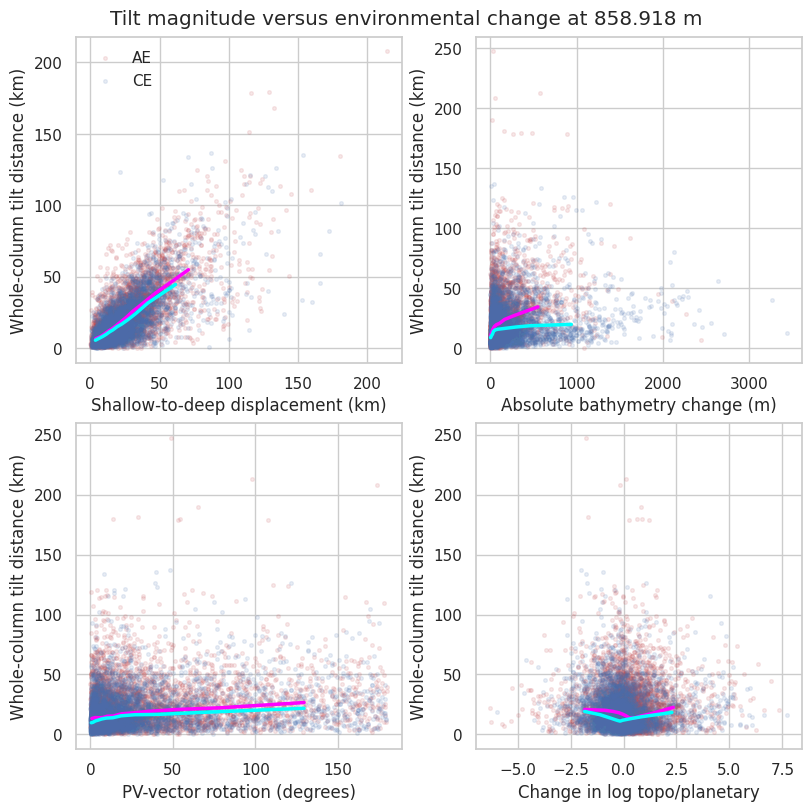

In [9]:
deep = matched[np.isclose(matched.Depth, DEPTHS[-1])].copy()
variables = {
    "spine_displacement_km": "Shallow-to-deep displacement (km)",
    "abs_delta_h_m": "Absolute bathymetry change (m)",
    "surface_rotation_PV_grad_theta_deg": "PV-vector rotation (degrees)",
    "delta_topo_plan_ratio": "Change in log topo/planetary",
}
fig, axes = plt.subplots(2, 2, figsize=(8,8), constrained_layout=True)
for ax, (column, label) in zip(axes.flat, variables.items()):
    for cyc in ["AE", "CE"]:
        part = deep[deep.Cyc.eq(cyc)].dropna(subset=[column, "TiltDis"])
        sample = part.sample(min(len(part), 5000), random_state=4) if len(part) else part
        ax.scatter(sample[column], sample.TiltDis, s=7, alpha=.12, color=palette[cyc], label=cyc)
        if len(part) > 20:
            xbins = pd.qcut(part[column], q=min(12, part[column].nunique()), duplicates="drop")
            trend = part.groupby(xbins, observed=True).agg(x=(column,"median"), y=("TiltDis","median"))
            clr = 'magenta' if cyc=='AE' else 'cyan'
            ax.plot(trend.x, trend.y, color=clr, lw=2.5)
    ax.set(xlabel=label, ylabel="Whole-column tilt distance (km)")
axes[0,0].legend(frameon=False); fig.suptitle(f"Tilt magnitude versus environmental change at {DEPTHS[-1]:g} m")
plt.show()

/scratch/pbs.9292413.kman.restech.unsw.edu.au/ipykernel_797530/3575608481.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho = spearmanr(use.TiltDis, use[variable]).statistic if len(use) >= 10 else np.nan
/scratch/pbs.9292413.kman.restech.unsw.edu.au/ipykernel_797530/3575608481.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho = spearmanr(use.TiltDis, use[variable]).statistic if len(use) >= 10 else np.nan
/scratch/pbs.9292413.kman.restech.unsw.edu.au/ipykernel_797530/3575608481.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho = spearmanr(use.TiltDis, use[variable]).statistic if len(use) >= 10 else np.nan
/scratch/pbs.9292413.kman.restech.unsw.edu.au/ipykernel_797530/3575608481.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho = spearmanr(use.TiltDis, use[variabl

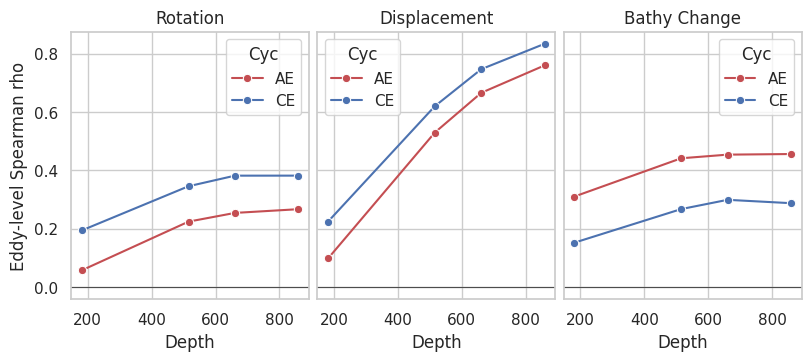

In [11]:
from scipy.stats import spearmanr

rows = []
for (cyc, z), part in matched.groupby(["Cyc", "Depth"]):
    eddy = part.groupby("Eddy").agg(TiltDis=("TiltDis","median"),
                                      rotation=("surface_rotation_PV_grad_theta_deg","median"),
                                      displacement=("spine_displacement_km","median"),
                                      bathy_change=("abs_delta_h_m","median"))
    for variable in ["rotation", "displacement", "bathy_change"]:
        use = eddy[["TiltDis", variable]].dropna()
        rho = spearmanr(use.TiltDis, use[variable]).statistic if len(use) >= 10 else np.nan
        rows.append({"Cyc":cyc, "Depth":z, "variable":variable, "rho":rho})
corr = pd.DataFrame(rows)
fig, axes = plt.subplots(1, 3, figsize=(8, 3.5), sharey=True, constrained_layout=True)
for ax, variable in zip(axes, ["rotation", "displacement", "bathy_change"]):
    sns.lineplot(data=corr[corr.variable.eq(variable)], x="Depth", y="rho", hue="Cyc", palette=palette, marker="o", ax=ax)
    ax.axhline(0, color="0.3", lw=.8); ax.set(title=variable.replace("_"," ").title(), ylabel="Eddy-level Spearman rho")
plt.show()